In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)

In [2]:
train = pd.read_csv('Train.csv')
test = pd.read_csv('Test.csv')

In [3]:
print('Train shape:', train.shape)
print('Test shape:', test.shape)
train.head()

Train shape: (2154021, 13)
Test shape: (280961, 13)


,sample_id,time,lat,lon,TWS_t,SPEI_01_t,SPEI_03_t,SPEI_06_t,SPEI_12_t,SOIL_MOISTURE_t,month_sin,month_cos,target
0,20020501_-55.5_-68.5,2002-05-01,-55.5,-68.5,0.876217,-1.584223,-1.701647,-2.015145,-1.912281,-1.827801,0.5,-0.866025,0.207665
1,20020501_-55.5_-67.5,2002-05-01,-55.5,-67.5,0.998124,-1.507424,-1.569591,-2.458965,-2.172938,-2.093158,0.5,-0.866025,0.634465
2,20020501_-54.5_-71.5,2002-05-01,-54.5,-71.5,0.813429,-1.473106,-1.151013,-0.524714,-0.908085,-0.932320,0.5,-0.866025,-0.337083
3,20020501_-54.5_-70.5,2002-05-01,-54.5,-70.5,0.841872,-1.460751,-1.487956,-0.588550,-0.936815,-0.928435,0.5,-0.866025,-0.148142
4,20020501_-54.5_-69.5,2002-05-01,-54.5,-69.5,0.872800,-1.275593,-1.729794,-0.243831,-0.870009,-1.053660,0.5,-0.866025,0.089539


In [4]:
# Check TWS_t_masked in test set
print(test['TWS_t_masked'].value_counts(dropna=False))

TWS_t_masked
True     186913
False     94048
Name: count, dtype: int64


In [5]:
# Check missing values in train
print(train.isnull().sum())

sample_id          0
time               0
lat                0
lon                0
TWS_t              0
SPEI_01_t          0
SPEI_03_t          0
SPEI_06_t          0
SPEI_12_t          0
SOIL_MOISTURE_t    0
month_sin          0
month_cos          0
target             0
dtype: int64


In [6]:
# Check missing values in test
print(test.isnull().sum())

ID                      0
time                    0
lat                     0
lon                     0
TWS_t              186913
SPEI_01_t               0
SPEI_03_t               0
SPEI_06_t               0
SPEI_12_t               0
SOIL_MOISTURE_t         0
month_sin               0
month_cos               0
TWS_t_masked            0
dtype: int64


In [7]:
train['time'] = pd.to_datetime(train['time'])

In [8]:
test['time'] = pd.to_datetime(test['time'])

In [9]:
print('Train date range:', train['time'].min(), 'to', train['time'].max())

Train date range: 2002-05-01 00:00:00 to 2015-08-01 00:00:00


In [10]:
print('Test date range:', test['time'].min(), 'to', test['time'].max())

Test date range: 2015-09-01 00:00:00 to 2018-12-01 00:00:00


In [11]:
print('Number of unique locations in train:', train[['lat','lon']].drop_duplicates().shape[0])

Number of unique locations in train: 15715


In [12]:
print('Number of unique dates in train:', train['time'].nunique())

Number of unique dates in train: 138


In [13]:
one_location = train[(train['lat'] == train['lat'].iloc[0]) & (train['lon'] == train['lon'].iloc[0])]

In [14]:
print(train['lat'].iloc[0])

-55.5


In [15]:
print(train['lat'].iloc[0], train['lon'].iloc[0])

-55.5 -68.5


In [16]:
mask = (train['lat'] == -55.5) & (train['lon'] == -68.5)

In [17]:
one_location = train[mask]

In [18]:
mask

0           True
1          False
2          False
3          False
4          False
           ...  
2154016    False
2154017    False
2154018    False
2154019    False
2154020    False
Length: 2154021, dtype: bool

In [19]:
one_location

,sample_id,time,lat,lon,TWS_t,SPEI_01_t,SPEI_03_t,SPEI_06_t,SPEI_12_t,SOIL_MOISTURE_t,month_sin,month_cos,target
0,20020501_-55.5_-68.5,2002-05-01,-55.5,-68.5,0.876217,-1.584223,-1.701647,-2.015145,-1.912281,-1.827801,5.000000e-01,-8.660254e-01,0.207665
15551,20020901_-55.5_-68.5,2002-09-01,-55.5,-68.5,1.036390,-2.008365,0.473211,-1.612974,-1.825995,-0.600919,-1.000000e+00,-1.836970e-16,1.531529
31084,20021001_-55.5_-68.5,2002-10-01,-55.5,-68.5,1.531529,-1.997204,-1.138877,-1.284561,-1.896380,-1.549100,-8.660254e-01,5.000000e-01,1.741992
46694,20021101_-55.5_-68.5,2002-11-01,-55.5,-68.5,1.741992,-0.482901,-1.829547,-0.641067,-1.704742,-0.174987,-5.000000e-01,8.660254e-01,1.379470
62272,20021201_-55.5_-68.5,2002-12-01,-55.5,-68.5,1.379470,0.037373,-1.459194,-0.845474,-1.572221,-0.223959,-2.449294e-16,1.000000e+00,1.484929
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2076085,20150401_-55.5_-68.5,2015-04-01,-55.5,-68.5,-1.017141,0.315011,0.727580,1.248538,0.046505,0.387031,8.660254e-01,-5.000000e-01,1.638603
2091730,20150501_-55.5_-68.5,2015-05-01,-55.5,-68.5,1.638603,-0.390930,-0.566241,0.816761,0.213157,-0.058680,5.000000e-01,-8.660254e-01,1.575986
2107313,20150601_-55.5_-68.5,2015-06-01,-55.5,-68.5,1.575986,-0.542441,-0.487769,0.594924,0.509071,-0.434053,1.224647e-16,-1.000000e+00,1.089499
2122894,20150701_-55.5_-68.5,2015-07-01,-55.5,-68.5,1.089499,0.073849,-0.671105,0.293773,1.019172,0.144939,-5.000000e-01,-8.660254e-01,0.516676


In [20]:
print(one_location.shape)
one_location.head()

(138, 13)


,sample_id,time,lat,lon,TWS_t,SPEI_01_t,SPEI_03_t,SPEI_06_t,SPEI_12_t,SOIL_MOISTURE_t,month_sin,month_cos,target
0,20020501_-55.5_-68.5,2002-05-01,-55.5,-68.5,0.876217,-1.584223,-1.701647,-2.015145,-1.912281,-1.827801,5.000000e-01,-8.660254e-01,0.207665
15551,20020901_-55.5_-68.5,2002-09-01,-55.5,-68.5,1.036390,-2.008365,0.473211,-1.612974,-1.825995,-0.600919,-1.000000e+00,-1.836970e-16,1.531529
31084,20021001_-55.5_-68.5,2002-10-01,-55.5,-68.5,1.531529,-1.997204,-1.138877,-1.284561,-1.896380,-1.549100,-8.660254e-01,5.000000e-01,1.741992
46694,20021101_-55.5_-68.5,2002-11-01,-55.5,-68.5,1.741992,-0.482901,-1.829547,-0.641067,-1.704742,-0.174987,-5.000000e-01,8.660254e-01,1.379470
62272,20021201_-55.5_-68.5,2002-12-01,-55.5,-68.5,1.379470,0.037373,-1.459194,-0.845474,-1.572221,-0.223959,-2.449294e-16,1.000000e+00,1.484929


In [21]:
import matplotlib.pyplot as plt

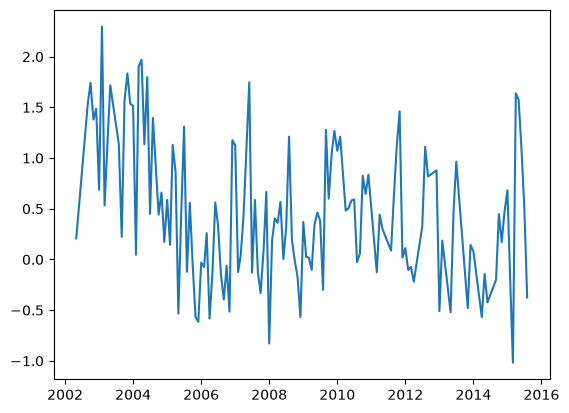

In [22]:
plt.plot(one_location['time'], one_location['target'])
plt.show()

In [23]:
mask2 = (train['lat'] > 20) & (train['lat'] < 25) & (train['lon'] > 0) & (train['lon'] < 10)

In [24]:
train[mask2][['lat','lon']].drop_duplicates()

,lat,lon
4849,20.5,1.5
4850,20.5,2.5
4851,20.5,3.5
4852,20.5,4.5
4853,20.5,5.5
4854,20.5,6.5
4855,20.5,7.5
4856,20.5,8.5
4857,20.5,9.5
4934,21.5,1.5


In [25]:
sahara = train[(train['lat'] == 20.5) & (train['lon'] == 1.5)]

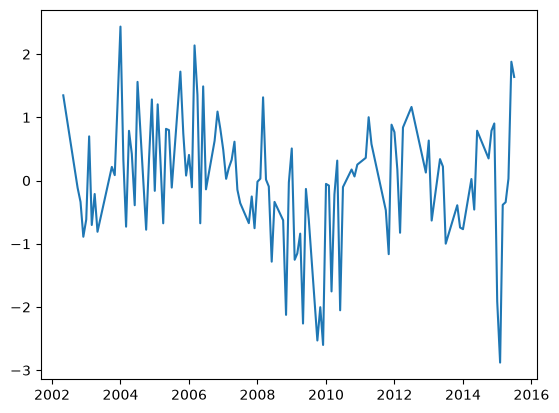

In [26]:
plt.plot(sahara['time'], sahara['target'])
plt.show()

In [27]:
mask3 = (train['lat'] > -5) & (train['lat'] < 0) & (train['lon'] > -65) & (train['lon'] < -55)

In [28]:
train[mask3][['lat','lon']].drop_duplicates()

,lat,lon
2623,-4.5,-64.5
2624,-4.5,-63.5
2625,-4.5,-62.5
2626,-4.5,-61.5
2627,-4.5,-60.5
2628,-4.5,-59.5
2629,-4.5,-58.5
2630,-4.5,-57.5
2631,-4.5,-56.5
2632,-4.5,-55.5


In [29]:
amazon = train[(train['lat'] == -4.5) & (train['lon'] == -64.5)]

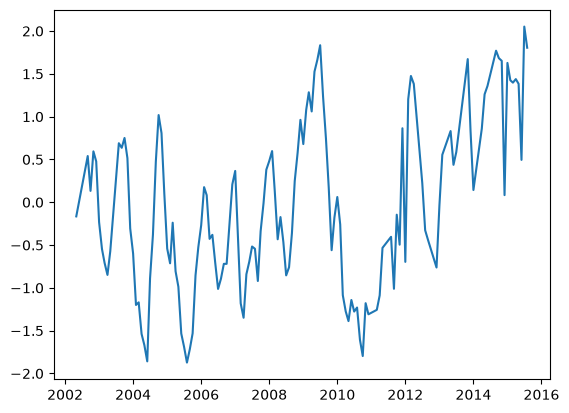

In [30]:
plt.plot(amazon['time'], amazon['target'])
plt.show()

In [31]:
sorted(train['time'].unique())[-20:]

[Timestamp('2013-06-01 00:00:00'),
 Timestamp('2013-07-01 00:00:00'),
 Timestamp('2013-11-01 00:00:00'),
 Timestamp('2013-12-01 00:00:00'),
 Timestamp('2014-01-01 00:00:00'),
 Timestamp('2014-04-01 00:00:00'),
 Timestamp('2014-05-01 00:00:00'),
 Timestamp('2014-06-01 00:00:00'),
 Timestamp('2014-09-01 00:00:00'),
 Timestamp('2014-10-01 00:00:00'),
 Timestamp('2014-11-01 00:00:00'),
 Timestamp('2014-12-01 00:00:00'),
 Timestamp('2015-01-01 00:00:00'),
 Timestamp('2015-02-01 00:00:00'),
 Timestamp('2015-03-01 00:00:00'),
 Timestamp('2015-04-01 00:00:00'),
 Timestamp('2015-05-01 00:00:00'),
 Timestamp('2015-06-01 00:00:00'),
 Timestamp('2015-07-01 00:00:00'),
 Timestamp('2015-08-01 00:00:00')]

In [32]:
cutoff_date = '2015-01-01'

In [33]:
train_split = train[train['time'] < cutoff_date]

In [34]:
train_split.tail()

,sample_id,time,lat,lon,TWS_t,SPEI_01_t,SPEI_03_t,SPEI_06_t,SPEI_12_t,SOIL_MOISTURE_t,month_sin,month_cos,target
2029087,20141201_83.5_-31.5,2014-12-01,83.5,-31.5,-0.102711,0.637607,-0.220272,-0.217408,-0.433357,0.146472,-2.449294e-16,1.0,-0.059242
2029088,20141201_83.5_-30.5,2014-12-01,83.5,-30.5,-0.100188,0.679935,-0.242168,-0.280753,-0.495029,0.287468,-2.449294e-16,1.0,-0.056268
2029089,20141201_83.5_-29.5,2014-12-01,83.5,-29.5,-0.097315,0.698454,-0.204371,-0.355307,-0.526294,0.059717,-2.449294e-16,1.0,-0.052766
2029090,20141201_83.5_-28.5,2014-12-01,83.5,-28.5,-0.094044,0.740460,-0.171357,-0.282683,-0.448951,-0.056535,-2.449294e-16,1.0,-0.048672
2029091,20141201_83.5_-27.5,2014-12-01,83.5,-27.5,-0.090322,0.774597,-0.099558,-0.311787,-0.410206,0.039373,-2.449294e-16,1.0,-0.043915


In [35]:
val_split = train[train['time'] >= cutoff_date]

In [36]:
val_split

,sample_id,time,lat,lon,TWS_t,SPEI_01_t,SPEI_03_t,SPEI_06_t,SPEI_12_t,SOIL_MOISTURE_t,month_sin,month_cos,target
2029092,20150101_-55.5_-68.5,2015-01-01,-55.5,-68.5,0.472663,1.882686,1.790518,1.238379,1.369909,1.272689,0.500000,0.866025,0.681904
2029093,20150101_-55.5_-67.5,2015-01-01,-55.5,-67.5,0.360642,1.516903,1.851917,1.403303,1.465251,1.213662,0.500000,0.866025,0.405528
2029094,20150101_-54.5_-71.5,2015-01-01,-54.5,-71.5,0.768374,1.869872,1.511838,0.363298,0.511012,0.877230,0.500000,0.866025,1.140511
2029095,20150101_-54.5_-70.5,2015-01-01,-54.5,-70.5,0.658309,2.229027,1.691826,0.677129,0.800001,0.265883,0.500000,0.866025,0.780808
2029096,20150101_-54.5_-69.5,2015-01-01,-54.5,-69.5,0.519130,2.047906,1.465639,0.639666,0.572917,0.149619,0.500000,0.866025,0.503092
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2154016,20150801_83.5_-31.5,2015-08-01,83.5,-31.5,-0.129312,0.124389,0.272274,0.295614,-0.462034,0.259676,-0.866025,-0.500000,-0.274003
2154017,20150801_83.5_-30.5,2015-08-01,83.5,-30.5,-0.124017,0.201431,0.254657,0.251846,-0.474233,0.157584,-0.866025,-0.500000,-0.271390
2154018,20150801_83.5_-29.5,2015-08-01,83.5,-29.5,-0.118744,0.216207,0.209865,0.229952,-0.446193,0.113499,-0.866025,-0.500000,-0.268540
2154019,20150801_83.5_-28.5,2015-08-01,83.5,-28.5,-0.113457,0.102946,0.209712,0.165252,-0.417426,-0.248551,-0.866025,-0.500000,-0.265412


In [37]:
train_split 

,sample_id,time,lat,lon,TWS_t,SPEI_01_t,SPEI_03_t,SPEI_06_t,SPEI_12_t,SOIL_MOISTURE_t,month_sin,month_cos,target
0,20020501_-55.5_-68.5,2002-05-01,-55.5,-68.5,0.876217,-1.584223,-1.701647,-2.015145,-1.912281,-1.827801,5.000000e-01,-0.866025,0.207665
1,20020501_-55.5_-67.5,2002-05-01,-55.5,-67.5,0.998124,-1.507424,-1.569591,-2.458965,-2.172938,-2.093158,5.000000e-01,-0.866025,0.634465
2,20020501_-54.5_-71.5,2002-05-01,-54.5,-71.5,0.813429,-1.473106,-1.151013,-0.524714,-0.908085,-0.932320,5.000000e-01,-0.866025,-0.337083
3,20020501_-54.5_-70.5,2002-05-01,-54.5,-70.5,0.841872,-1.460751,-1.487956,-0.588550,-0.936815,-0.928435,5.000000e-01,-0.866025,-0.148142
4,20020501_-54.5_-69.5,2002-05-01,-54.5,-69.5,0.872800,-1.275593,-1.729794,-0.243831,-0.870009,-1.053660,5.000000e-01,-0.866025,0.089539
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2029087,20141201_83.5_-31.5,2014-12-01,83.5,-31.5,-0.102711,0.637607,-0.220272,-0.217408,-0.433357,0.146472,-2.449294e-16,1.000000,-0.059242
2029088,20141201_83.5_-30.5,2014-12-01,83.5,-30.5,-0.100188,0.679935,-0.242168,-0.280753,-0.495029,0.287468,-2.449294e-16,1.000000,-0.056268
2029089,20141201_83.5_-29.5,2014-12-01,83.5,-29.5,-0.097315,0.698454,-0.204371,-0.355307,-0.526294,0.059717,-2.449294e-16,1.000000,-0.052766
2029090,20141201_83.5_-28.5,2014-12-01,83.5,-28.5,-0.094044,0.740460,-0.171357,-0.282683,-0.448951,-0.056535,-2.449294e-16,1.000000,-0.048672


In [38]:
print('Train split shape:', train_split.shape)
print('Val split shape:', val_split.shape)
print('Train split date range:', train_split['time'].min(), 'to', train_split['time'].max())
print('Val split date range:', val_split['time'].min(), 'to', val_split['time'].max())

Train split shape: (2029092, 13)
Val split shape: (124929, 13)
Train split date range: 2002-05-01 00:00:00 to 2014-12-01 00:00:00
Val split date range: 2015-01-01 00:00:00 to 2015-08-01 00:00:00


In [39]:
features = ['TWS_t', 'SPEI_01_t', 'SPEI_03_t', 'SPEI_06_t', 'SPEI_12_t', 'SOIL_MOISTURE_t', 'month_sin', 'month_cos']

In [40]:
X_train = train_split[features]
y_train = train_split['target']

In [41]:
X_train

,TWS_t,SPEI_01_t,SPEI_03_t,SPEI_06_t,SPEI_12_t,SOIL_MOISTURE_t,month_sin,month_cos
0,0.876217,-1.584223,-1.701647,-2.015145,-1.912281,-1.827801,5.000000e-01,-0.866025
1,0.998124,-1.507424,-1.569591,-2.458965,-2.172938,-2.093158,5.000000e-01,-0.866025
2,0.813429,-1.473106,-1.151013,-0.524714,-0.908085,-0.932320,5.000000e-01,-0.866025
3,0.841872,-1.460751,-1.487956,-0.588550,-0.936815,-0.928435,5.000000e-01,-0.866025
4,0.872800,-1.275593,-1.729794,-0.243831,-0.870009,-1.053660,5.000000e-01,-0.866025
...,...,...,...,...,...,...,...,...
2029087,-0.102711,0.637607,-0.220272,-0.217408,-0.433357,0.146472,-2.449294e-16,1.000000
2029088,-0.100188,0.679935,-0.242168,-0.280753,-0.495029,0.287468,-2.449294e-16,1.000000
2029089,-0.097315,0.698454,-0.204371,-0.355307,-0.526294,0.059717,-2.449294e-16,1.000000
2029090,-0.094044,0.740460,-0.171357,-0.282683,-0.448951,-0.056535,-2.449294e-16,1.000000


In [42]:
y_train 

0          0.207665
1          0.634465
2         -0.337083
3         -0.148142
4          0.089539
             ...   
2029087   -0.059242
2029088   -0.056268
2029089   -0.052766
2029090   -0.048672
2029091   -0.043915
Name: target, Length: 2029092, dtype: float64

In [43]:
X_val = val_split[features]
y_val = val_split['target']

In [44]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [45]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 0.79, 0. ,-0.05,...,-0. ,-0.01,-0.01]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['TWS_t','SPEI_01_t','SPEI_03_t',...,'SOIL_MOISTURE_t','month_sin', 'month_cos']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.02824
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,8


In [46]:
predictions = model.predict(X_val)

In [47]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_val, predictions))
print('Validation RMSE:', rmse)

Validation RMSE: 0.8194068517880296


In [48]:
print('Target mean:', y_val.mean())
print('Target std:', y_val.std())

Target mean: -0.13594281553279744
Target std: 0.9271571319307155


In [49]:
y_train.mean()

np.float64(0.12780034988332545)

In [50]:
naive_prediction = np.full(len(y_val), y_train.mean())
naive_rmse = np.sqrt(mean_squared_error(y_val, naive_prediction))
print('Naive (mean-guessing) RMSE:', naive_rmse)

Naive (mean-guessing) RMSE: 0.963936680349178


In [51]:
X_full_train = train[features]
y_full_train = train['target']

In [52]:
final_model = LinearRegression()
final_model.fit(X_full_train, y_full_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 0.77, 0. ,-0.05,..., 0. ,-0.01,-0.01]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['TWS_t','SPEI_01_t','SPEI_03_t',...,'SOIL_MOISTURE_t','month_sin', 'month_cos']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.02896
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,8


In [53]:
X_test = test[features]

In [54]:
fill_value = train['TWS_t'].mean()
X_test = X_test.fillna({'TWS_t': fill_value})

In [55]:
test_predictions = final_model.predict(X_test)

In [56]:
submission = pd.DataFrame({'ID': test['ID'], 'Target': test_predictions})
submission.head()

,ID,Target
0,20150901_-55.5_-68.5,-0.212023
1,20150901_-55.5_-67.5,-0.339885
2,20150901_-54.5_-71.5,0.502114
3,20150901_-54.5_-70.5,0.348303
4,20150901_-54.5_-69.5,0.207769


In [57]:
submission.to_csv('submission.csv', index=False)

In [58]:
features_v2 = ['TWS_t', 'SPEI_01_t', 'SPEI_03_t', 'SPEI_06_t', 'SPEI_12_t', 'SOIL_MOISTURE_t', 'month_sin', 'month_cos', 'lat', 'lon']

In [59]:
X_train_v2 = train_split[features_v2]
X_val_v2 = val_split[features_v2]

In [60]:
X_train_v2

,TWS_t,SPEI_01_t,SPEI_03_t,SPEI_06_t,SPEI_12_t,SOIL_MOISTURE_t,month_sin,month_cos,lat,lon
0,0.876217,-1.584223,-1.701647,-2.015145,-1.912281,-1.827801,5.000000e-01,-0.866025,-55.5,-68.5
1,0.998124,-1.507424,-1.569591,-2.458965,-2.172938,-2.093158,5.000000e-01,-0.866025,-55.5,-67.5
2,0.813429,-1.473106,-1.151013,-0.524714,-0.908085,-0.932320,5.000000e-01,-0.866025,-54.5,-71.5
3,0.841872,-1.460751,-1.487956,-0.588550,-0.936815,-0.928435,5.000000e-01,-0.866025,-54.5,-70.5
4,0.872800,-1.275593,-1.729794,-0.243831,-0.870009,-1.053660,5.000000e-01,-0.866025,-54.5,-69.5
...,...,...,...,...,...,...,...,...,...,...
2029087,-0.102711,0.637607,-0.220272,-0.217408,-0.433357,0.146472,-2.449294e-16,1.000000,83.5,-31.5
2029088,-0.100188,0.679935,-0.242168,-0.280753,-0.495029,0.287468,-2.449294e-16,1.000000,83.5,-30.5
2029089,-0.097315,0.698454,-0.204371,-0.355307,-0.526294,0.059717,-2.449294e-16,1.000000,83.5,-29.5
2029090,-0.094044,0.740460,-0.171357,-0.282683,-0.448951,-0.056535,-2.449294e-16,1.000000,83.5,-28.5


In [61]:
X_val_v2

,TWS_t,SPEI_01_t,SPEI_03_t,SPEI_06_t,SPEI_12_t,SOIL_MOISTURE_t,month_sin,month_cos,lat,lon
2029092,0.472663,1.882686,1.790518,1.238379,1.369909,1.272689,0.500000,0.866025,-55.5,-68.5
2029093,0.360642,1.516903,1.851917,1.403303,1.465251,1.213662,0.500000,0.866025,-55.5,-67.5
2029094,0.768374,1.869872,1.511838,0.363298,0.511012,0.877230,0.500000,0.866025,-54.5,-71.5
2029095,0.658309,2.229027,1.691826,0.677129,0.800001,0.265883,0.500000,0.866025,-54.5,-70.5
2029096,0.519130,2.047906,1.465639,0.639666,0.572917,0.149619,0.500000,0.866025,-54.5,-69.5
...,...,...,...,...,...,...,...,...,...,...
2154016,-0.129312,0.124389,0.272274,0.295614,-0.462034,0.259676,-0.866025,-0.500000,83.5,-31.5
2154017,-0.124017,0.201431,0.254657,0.251846,-0.474233,0.157584,-0.866025,-0.500000,83.5,-30.5
2154018,-0.118744,0.216207,0.209865,0.229952,-0.446193,0.113499,-0.866025,-0.500000,83.5,-29.5
2154019,-0.113457,0.102946,0.209712,0.165252,-0.417426,-0.248551,-0.866025,-0.500000,83.5,-28.5


In [62]:
model_v2 = LinearRegression()
model_v2.fit(X_train_v2, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ 0.79, 0. ,-0.05,...,-0.01, 0. ,-0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](10,)","['TWS_t','SPEI_01_t','SPEI_03_t',...,'month_cos','lat','lon']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.002609
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,10


In [63]:
predictions_v2 = model_v2.predict(X_val_v2)
rmse_v2 = np.sqrt(mean_squared_error(y_val, predictions_v2))
print('Validation RMSE with lat/lon:', rmse_v2)

Validation RMSE with lat/lon: 0.8187650813645952


## Building a Random Forest Model

In [64]:
from sklearn.ensemble import RandomForestRegressor

In [65]:
rf_model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)

In [66]:
rf_model.fit(X_train_v2, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_

In [67]:
predictions_rf = rf_model.predict(X_val_v2)
rmse_rf = np.sqrt(mean_squared_error(y_val, predictions_rf))
print('Validation RMSE (Random Forest):', rmse_rf)

Validation RMSE (Random Forest): 0.8058162866047963


In [68]:
test[features_v2].isnull().sum()

TWS_t              186913
SPEI_01_t               0
SPEI_03_t               0
SPEI_06_t               0
SPEI_12_t               0
SOIL_MOISTURE_t         0
month_sin               0
month_cos               0
lat                     0
lon                     0
dtype: int64

In [69]:
tws_fill_value = train['TWS_t'].mean()
print(tws_fill_value)

0.11699509327923295


In [70]:
test['TWS_t_filled'] = test['TWS_t'].fillna(tws_fill_value)

In [71]:
print(test['TWS_t_filled'].isnull().sum())

0


In [72]:
features_final = ['TWS_t_filled', 'SPEI_01_t', 'SPEI_03_t', 'SPEI_06_t', 'SPEI_12_t', 'SOIL_MOISTURE_t', 'month_sin', 'month_cos', 'lat', 'lon']

In [73]:
train['TWS_t_filled'] = train['TWS_t'].fillna(tws_fill_value)

In [74]:
X_train_final = train[features_final]
y_train_final = train['target']

In [75]:
final_model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
final_model.fit(X_train_final, y_train_final)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_

In [76]:
X_test_final = test[features_final]
test_predictions = final_model.predict(X_test_final)

In [77]:
print(test_predictions[:10])
print('Number of predictions:', len(test_predictions))

[-0.26754787 -0.23880176  0.42927705  0.26958568  0.15715849  0.04134457
 -0.10102326 -0.2734449   0.28547374  0.33040155]
Number of predictions: 280961


In [78]:
submission = pd.DataFrame({'ID': test['ID'], 'Target': test_predictions})

In [79]:
submission.head()

,ID,Target
0,20150901_-55.5_-68.5,-0.267548
1,20150901_-55.5_-67.5,-0.238802
2,20150901_-54.5_-71.5,0.429277
3,20150901_-54.5_-70.5,0.269586
4,20150901_-54.5_-69.5,0.157158


In [80]:
submission.to_csv('submission.csv', index=False)

In [81]:
np.random.seed(42)

In [82]:
mask_sim = np.random.rand(len(val_split)) < 0.66

In [83]:
val_split_masked = val_split.copy()

In [84]:
val_split_masked.loc[mask_sim, 'TWS_t'] = np.nan

In [85]:
print(val_split_masked['TWS_t'].isnull().sum())
print(len(val_split_masked))

82550
124929


In [86]:
val_split_masked.head()

,sample_id,time,lat,lon,TWS_t,SPEI_01_t,SPEI_03_t,SPEI_06_t,SPEI_12_t,SOIL_MOISTURE_t,month_sin,month_cos,target
2029092,20150101_-55.5_-68.5,2015-01-01,-55.5,-68.5,NaN,1.882686,1.790518,1.238379,1.369909,1.272689,0.5,0.866025,0.681904
2029093,20150101_-55.5_-67.5,2015-01-01,-55.5,-67.5,0.360642,1.516903,1.851917,1.403303,1.465251,1.213662,0.5,0.866025,0.405528
2029094,20150101_-54.5_-71.5,2015-01-01,-54.5,-71.5,0.768374,1.869872,1.511838,0.363298,0.511012,0.877230,0.5,0.866025,1.140511
2029095,20150101_-54.5_-70.5,2015-01-01,-54.5,-70.5,NaN,2.229027,1.691826,0.677129,0.800001,0.265883,0.5,0.866025,0.780808
2029096,20150101_-54.5_-69.5,2015-01-01,-54.5,-69.5,NaN,2.047906,1.465639,0.639666,0.572917,0.149619,0.5,0.866025,0.503092


In [87]:
location_avg_tws = train_split.groupby(['lat', 'lon'])['TWS_t'].mean()

In [88]:
location_avg_tws.head()

lat    lon  
-55.5  -68.5    0.455069
       -67.5    0.512933
-54.5  -71.5    0.361837
       -70.5    0.440816
       -69.5    0.501847
Name: TWS_t, dtype: float64

In [89]:
location_avg_tws

lat    lon  
-55.5  -68.5    0.455069
       -67.5    0.512933
-54.5  -71.5    0.361837
       -70.5    0.440816
       -69.5    0.501847
                  ...   
 83.5  -31.5    0.732736
       -30.5    0.732539
       -29.5    0.732324
       -28.5    0.732089
       -27.5    0.731831
Name: TWS_t, Length: 15715, dtype: float64

In [90]:
def fill_missing_tws(df, location_avg):
    df = df.copy()
    df['TWS_t_was_missing'] = df['TWS_t'].isnull().astype(int)
    df['TWS_t'] = df.apply(
        lambda row: location_avg.get((row['lat'], row['lon']), location_avg.mean())
        if pd.isnull(row['TWS_t']) else row['TWS_t'],
        axis=1
    )
    return df

In [91]:
val_split_masked_filled = fill_missing_tws(val_split_masked, location_avg_tws)

In [92]:
print(val_split_masked_filled['TWS_t'].isnull().sum())
print(val_split_masked_filled['TWS_t_was_missing'].sum())

0
82550


In [94]:
val_split_masked_filled

,sample_id,time,lat,lon,TWS_t,SPEI_01_t,SPEI_03_t,SPEI_06_t,SPEI_12_t,SOIL_MOISTURE_t,month_sin,month_cos,target,TWS_t_was_missing
2029092,20150101_-55.5_-68.5,2015-01-01,-55.5,-68.5,0.455069,1.882686,1.790518,1.238379,1.369909,1.272689,0.500000,0.866025,0.681904,1
2029093,20150101_-55.5_-67.5,2015-01-01,-55.5,-67.5,0.360642,1.516903,1.851917,1.403303,1.465251,1.213662,0.500000,0.866025,0.405528,0
2029094,20150101_-54.5_-71.5,2015-01-01,-54.5,-71.5,0.768374,1.869872,1.511838,0.363298,0.511012,0.877230,0.500000,0.866025,1.140511,0
2029095,20150101_-54.5_-70.5,2015-01-01,-54.5,-70.5,0.440816,2.229027,1.691826,0.677129,0.800001,0.265883,0.500000,0.866025,0.780808,1
2029096,20150101_-54.5_-69.5,2015-01-01,-54.5,-69.5,0.501847,2.047906,1.465639,0.639666,0.572917,0.149619,0.500000,0.866025,0.503092,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2154016,20150801_83.5_-31.5,2015-08-01,83.5,-31.5,0.732736,0.124389,0.272274,0.295614,-0.462034,0.259676,-0.866025,-0.500000,-0.274003,1
2154017,20150801_83.5_-30.5,2015-08-01,83.5,-30.5,0.732539,0.201431,0.254657,0.251846,-0.474233,0.157584,-0.866025,-0.500000,-0.271390,1
2154018,20150801_83.5_-29.5,2015-08-01,83.5,-29.5,0.732324,0.216207,0.209865,0.229952,-0.446193,0.113499,-0.866025,-0.500000,-0.268540,1
2154019,20150801_83.5_-28.5,2015-08-01,83.5,-28.5,0.732089,0.102946,0.209712,0.165252,-0.417426,-0.248551,-0.866025,-0.500000,-0.265412,1


In [96]:
features_v3 = features_v2 + ['TWS_t_was_missing']
features_v3

['TWS_t',
 'SPEI_01_t',
 'SPEI_03_t',
 'SPEI_06_t',
 'SPEI_12_t',
 'SOIL_MOISTURE_t',
 'month_sin',
 'month_cos',
 'lat',
 'lon',
 'TWS_t_was_missing']

In [97]:
train_split_filled = train_split.copy()
train_split_filled['TWS_t_was_missing'] = 0

In [98]:
train_split_filled

,sample_id,time,lat,lon,TWS_t,SPEI_01_t,SPEI_03_t,SPEI_06_t,SPEI_12_t,SOIL_MOISTURE_t,month_sin,month_cos,target,TWS_t_was_missing
0,20020501_-55.5_-68.5,2002-05-01,-55.5,-68.5,0.876217,-1.584223,-1.701647,-2.015145,-1.912281,-1.827801,5.000000e-01,-0.866025,0.207665,0
1,20020501_-55.5_-67.5,2002-05-01,-55.5,-67.5,0.998124,-1.507424,-1.569591,-2.458965,-2.172938,-2.093158,5.000000e-01,-0.866025,0.634465,0
2,20020501_-54.5_-71.5,2002-05-01,-54.5,-71.5,0.813429,-1.473106,-1.151013,-0.524714,-0.908085,-0.932320,5.000000e-01,-0.866025,-0.337083,0
3,20020501_-54.5_-70.5,2002-05-01,-54.5,-70.5,0.841872,-1.460751,-1.487956,-0.588550,-0.936815,-0.928435,5.000000e-01,-0.866025,-0.148142,0
4,20020501_-54.5_-69.5,2002-05-01,-54.5,-69.5,0.872800,-1.275593,-1.729794,-0.243831,-0.870009,-1.053660,5.000000e-01,-0.866025,0.089539,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2029087,20141201_83.5_-31.5,2014-12-01,83.5,-31.5,-0.102711,0.637607,-0.220272,-0.217408,-0.433357,0.146472,-2.449294e-16,1.000000,-0.059242,0
2029088,20141201_83.5_-30.5,2014-12-01,83.5,-30.5,-0.100188,0.679935,-0.242168,-0.280753,-0.495029,0.287468,-2.449294e-16,1.000000,-0.056268,0
2029089,20141201_83.5_-29.5,2014-12-01,83.5,-29.5,-0.097315,0.698454,-0.204371,-0.355307,-0.526294,0.059717,-2.449294e-16,1.000000,-0.052766,0
2029090,20141201_83.5_-28.5,2014-12-01,83.5,-28.5,-0.094044,0.740460,-0.171357,-0.282683,-0.448951,-0.056535,-2.449294e-16,1.000000,-0.048672,0


In [99]:
X_train_v3 = train_split_filled[features_v3]
X_val_v3 = val_split_masked_filled[features_v3]

rf_model_v3 = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf_model_v3.fit(X_train_v3, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_

In [100]:
predictions_v3 = rf_model_v3.predict(X_val_v3)
rmse_v3 = np.sqrt(mean_squared_error(y_val, predictions_v3))
print('Validation RMSE (realistic masking):', rmse_v3)

Validation RMSE (realistic masking): 1.0157901865292847


In [101]:
from sklearn.ensemble import HistGradientBoostingRegressor

In [102]:
X_train_v4 = train_split[features_v2].copy()
X_train_v4['TWS_t_was_missing'] = 0

X_val_v4 = val_split_masked[features_v2].copy()
X_val_v4['TWS_t_was_missing'] = val_split_masked['TWS_t'].isnull().astype(int)

In [103]:
hgb_model = HistGradientBoostingRegressor(max_iter=100, max_depth=8, random_state=42)
hgb_model.fit(X_train_v4, y_train)

,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",8
,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the subsampling in thebinning process, and the train/validation data split if early stoppingis enabled.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'gamma', 'poisson', 'quantile'}, default='squared_error'The loss function to use in the boosting process. Note that the""squared error"", ""gamma"" and ""poisson"" losses actually implement""half least squares loss"", ""half gamma deviance"" and ""half poissondeviance"" to simplify the computation of the gradient. Furthermore,""gamma"" and ""poisson"" losses internally use a log-link, ""gamma""requires ``y > 0`` and ""poisson"" requires ``y >= 0``.""quantile"" uses the pinball loss... versionchanged:: 0.23 Added option 'poisson'... versionchanged:: 1.1 Added option 'quantile'... versionchanged:: 1.3 Added option 'gamma'.",'squared_error'
,"quantile quantile: float, default=NoneIf loss is ""quantile"", this parameter specifies which quantile to be estimatedand must be between 0 and 1.",None
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees.",100
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255


In [104]:
predictions_hgb = hgb_model.predict(X_val_v4)
rmse_hgb = np.sqrt(mean_squared_error(y_val, predictions_hgb))
print('Validation RMSE (HistGradientBoosting, real NaNs):', rmse_hgb)

Validation RMSE (HistGradientBoosting, real NaNs): 0.9328167408669064


In [105]:
X_full = train[features_v2].copy()
X_full['TWS_t_was_missing'] = 0
y_full = train['target']

final_model = HistGradientBoostingRegressor(max_iter=100, max_depth=8, random_state=42)
final_model.fit(X_full, y_full)

,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",8
,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the subsampling in thebinning process, and the train/validation data split if early stoppingis enabled.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'gamma', 'poisson', 'quantile'}, default='squared_error'The loss function to use in the boosting process. Note that the""squared error"", ""gamma"" and ""poisson"" losses actually implement""half least squares loss"", ""half gamma deviance"" and ""half poissondeviance"" to simplify the computation of the gradient. Furthermore,""gamma"" and ""poisson"" losses internally use a log-link, ""gamma""requires ``y > 0`` and ""poisson"" requires ``y >= 0``.""quantile"" uses the pinball loss... versionchanged:: 0.23 Added option 'poisson'... versionchanged:: 1.1 Added option 'quantile'... versionchanged:: 1.3 Added option 'gamma'.",'squared_error'
,"quantile quantile: float, default=NoneIf loss is ""quantile"", this parameter specifies which quantile to be estimatedand must be between 0 and 1.",None
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees.",100
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255


In [106]:
X_test_final = test[features_v2].copy()
X_test_final['TWS_t_was_missing'] = test['TWS_t_masked'].astype(int)

test_predictions = final_model.predict(X_test_final)

In [107]:
submission = pd.DataFrame({
    'ID': test['ID'],
    'Target': test_predictions
})
submission.to_csv('submission.csv', index=False)
print(submission.head())
print(submission.shape)

                     ID    Target
0  20150901_-55.5_-68.5 -0.134407
1  20150901_-55.5_-67.5 -0.195981
2  20150901_-54.5_-71.5  0.496759
3  20150901_-54.5_-70.5  0.360430
4  20150901_-54.5_-69.5  0.197906
(280961, 2)
